In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/AIProject

 scenic-main  'scenic-main (1).zip'   Untitled0.ipynb


In [ ]:
scenic_path = '/content/drive/MyDrive/AIProject/scenic-main'

In [ ]:
import sys
sys.path.append(scenic_path)

In [ ]:
from PIL import Image


In [ ]:
!pip install torch torchvision transformers pillow

from transformers import OwlViTProcessor, OwlViTForObjectDetection
from PIL import Image
import requests

# Load the model
processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")

# Load an image
from google.colab import files
uploaded = files.upload()  # pick your image
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

# Define your query
text_query = ["tree", "bush"]

# Preprocess and run
inputs = processor(text=text_query, images=image, return_tensors="pt")
outputs = model(**inputs)

# outputs now has predicted boxes and labels


In [ ]:
from PIL import Image
from IPython.display import display  # <- Colab-friendly display

# Replace with your uploaded image filename
image_path = "free-nature-images.jpg"

# Open and convert to RGB
image = Image.open(image_path).convert("RGB")

# Display inline in Colab
display(image)


In [ ]:
from transformers import OwlViTProcessor, OwlViTForObjectDetection
import torch

# Load the processor and model
processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")

# Define your text query
text_query = ["tree", "Bush"]  # can be a list of multiple queries

# Preprocess image and text
inputs = processor(text=text_query, images=image, return_tensors="pt")

# Forward pass
outputs = model(**inputs)

# The outputs contain bounding boxes, scores, and labels
# You can print them or visualize next
print(outputs)


In [ ]:
import torch

# Boxes
boxes = outputs.pred_boxes[0]  # shape: [num_boxes, 4]

# Scores and labels
probs = outputs.logits[0].softmax(-1)  # softmax over classes
scores, labels = probs.max(-1)          # get max probability and corresponding class index

# If you want class names (assuming using processor.tokenizer)
classes = [processor.tokenizer.decode([label]) for label in labels]

# Print first 5 predictions for sanity check
for i in range(5):
    print(f"Box: {boxes[i]}, Class: {classes[i]}, Score: {scores[i].item():.2f}")


Box: tensor([0.0750, 0.0667, 0.1492, 0.1351], grad_fn=<SelectBackward0>), Class: !, Score: 0.86
Box: tensor([0.1415, 0.0512, 0.2330, 0.1006], grad_fn=<SelectBackward0>), Class: !, Score: 0.86
Box: tensor([0.1118, 0.0233, 0.0594, 0.0422], grad_fn=<SelectBackward0>), Class: !, Score: 0.87
Box: tensor([0.1818, 0.0294, 0.1199, 0.0594], grad_fn=<SelectBackward0>), Class: !, Score: 0.86
Box: tensor([0.3003, 0.1130, 0.6057, 0.2277], grad_fn=<SelectBackward0>), Class: !, Score: 0.92


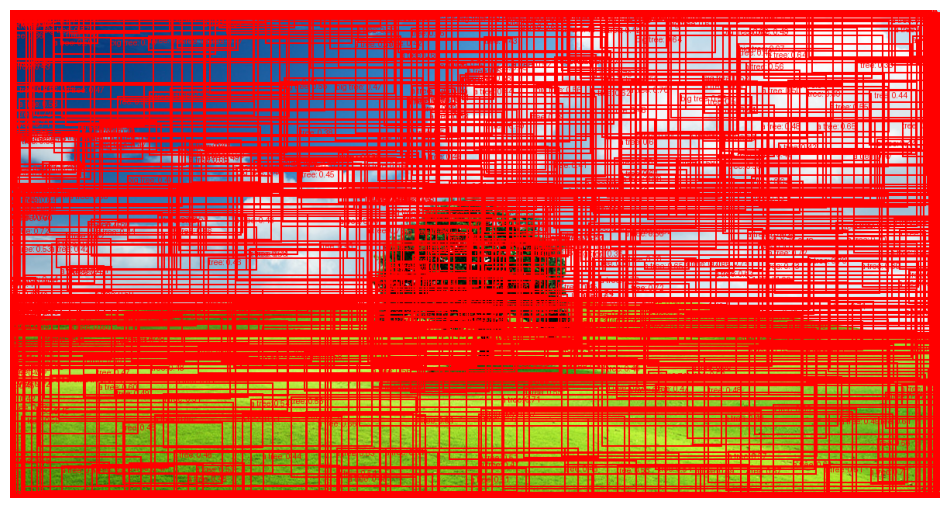

In [ ]:
import torch
import matplotlib.pyplot as plt
from PIL import ImageDraw, ImageFont

# Top-k boxes to visualize
top_k = 5
threshold = 0.3  # confidence threshold

# OwlViT outputs
boxes = outputs.pred_boxes[0]         # [num_boxes, 4]
logits = outputs.logits[0]            # [num_boxes, num_classes]

# Compute scores and labels
scores, labels = torch.max(torch.softmax(logits, dim=-1), dim=-1)
indices = torch.argsort(scores, descending=True)[:top_k]

image_with_boxes = image.copy()
draw = ImageDraw.Draw(image_with_boxes)
W, H = image.size

# Optional font
try:
    font = ImageFont.truetype("arial.ttf", 16)
except:
    font = ImageFont.load_default()

for i in indices:
    score = scores[i].item()
    if score < threshold:
        continue
    label_idx = labels[i].item()
    cls_name = processor.tokenizer.convert_ids_to_tokens([label_idx])[0]

    cx, cy, w, h = boxes[i].tolist()
    x0 = max((cx - w/2) * W, 0)
    y0 = max((cy - h/2) * H, 0)
    x1 = min((cx + w/2) * W, W)
    y1 = min((cy + h/2) * H, H)

    # Skip invalid boxes
    if x1 <= x0 or y1 <= y0:
        continue

    draw.rectangle([x0, y0, x1, y1], outline="red", width=2)
    draw.text((x0, y0-10), f"{cls_name} {score:.2f}", fill="red", font=font)

plt.figure(figsize=(12,8))
plt.imshow(image_with_boxes)
plt.axis('off')
plt.show()


This notebook implements the baseline version of the OWL-ViT object detection model using the google/owlvit-base-patch32 checkpoint. The code loads an image and processes a simple text query (e.g., “tree” or “bush”) to produce bounding boxes for all detected objects that the model believes match the prompt. OWL-ViT uses joint vision–language embeddings, allowing it to localize objects without being trained on specific classes.

This baseline version displays all predicted bounding boxes, regardless of confidence level. It also uses generic text prompts, which means the model attempts to match broad concepts. Because OWL-ViT returns a large number of candidate predictions by default, the visual output includes many overlapping or inaccurate bounding boxes. This baseline demonstrates the model’s raw, unfiltered behavior, which we later refine through prompt engineering and threshold adjustments.